# Temporal Gesture Classifier — GRU-64 Training

Train a **GRU-64** model on sequence data collected via `SequenceCollector`.

- **Input**: NPZ file with `sequences` (N, 20, 93) and `labels` (N,)
- **Output**: TFLite model at `model/temporal_classifier/temporal_classifier.tflite`
- **Architecture**: Input(20, 93) → GRU(64, unroll=True) → Dropout(0.3) → Dense(5, softmax)
- **Design doc**: `docs/ai/design/feature-temporal-gru64.md`

In [8]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
# --- Configuration ---
NPZ_PATH = "model/temporal_classifier/keypoint_sequences.npz"
KERAS_SAVE_PATH = "model/temporal_classifier/temporal_classifier.h5"
TFLITE_SAVE_PATH = "model/temporal_classifier/temporal_classifier.tflite"

WINDOW_SIZE = 20
NUM_FEATURES = 93
NUM_CLASSES = 5
HIDDEN_UNITS = 64

CLASS_NAMES = ["null", "pointer_move", "left_click", "drag_hold", "scroll_mode"]

## Load & Explore Data

In [10]:
# --- Load sequence data ---
data = np.load(NPZ_PATH)
sequences = data["sequences"]  # (N, 20, 93)
labels = data["labels"]        # (N,)

print(f"Sequences shape: {sequences.shape}")
print(f"Labels shape:    {labels.shape}")
print(f"Unique classes:  {np.unique(labels)}")
print(f"dtype:           {sequences.dtype}")

Sequences shape: (1420, 20, 93)
Labels shape:    (1420,)
Unique classes:  [1 2 3]
dtype:           float32


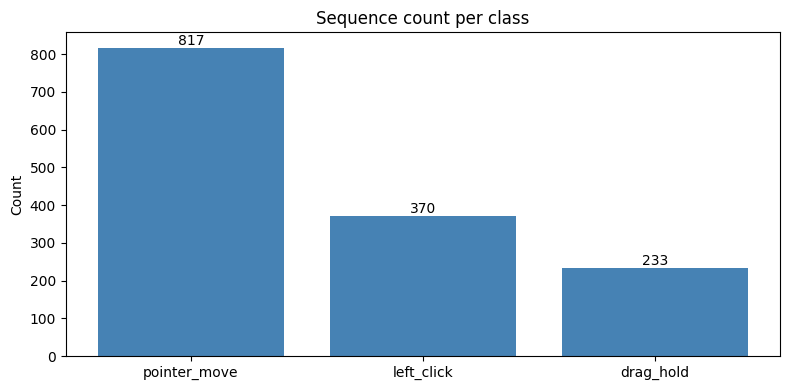

In [11]:
# --- Class distribution ---
unique, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([CLASS_NAMES[i] for i in unique], counts, color="steelblue")
ax.bar_label(bars)
ax.set_title("Sequence count per class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Train / Validation Split

In [12]:
# --- Train / Validation split (75/25, stratified) ---
X_train, X_val, y_train, y_val = train_test_split(
    sequences, labels, test_size=0.25, random_state=42, stratify=labels
)
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}")

Train: 1065  |  Val: 355


## Build & Train GRU-64 Model

In [13]:
# --- Build GRU-64 model ---
model = tf.keras.Sequential([
    tf.keras.layers.Input((WINDOW_SIZE, NUM_FEATURES)),
    tf.keras.layers.GRU(HIDDEN_UNITS, unroll=True, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 (None, 64)                30528     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 325       
                                                                 
Total params: 30853 (120.52 KB)
Trainable params: 30853 (120.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
# --- Train ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        KERAS_SAVE_PATH, save_best_only=True, monitor="val_accuracy"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=20, restore_best_weights=True, monitor="val_accuracy"
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
)

Epoch 1/300
9/9 [==============================] - 2s 61ms/step - loss: 1.0934 - accuracy: 0.6085 - val_loss: 0.7372 - val_accuracy: 0.6563
Epoch 2/300
9/9 [==============================] - 0s 8ms/step - loss: 0.6234 - accuracy: 0.7455 - val_loss: 0.4940 - val_accuracy: 0.8254
Epoch 3/300
9/9 [==============================] - 0s 8ms/step - loss: 0.4358 - accuracy: 0.8310 - val_loss: 0.3768 - val_accuracy: 0.8507
Epoch 4/300
1/9 [==>...........................] - ETA: 0s - loss: 0.3630 - accuracy: 0.8672

/home/sakana/miniconda3/envs/sign/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


9/9 [==============================] - 0s 8ms/step - loss: 0.3397 - accuracy: 0.8347 - val_loss: 0.3155 - val_accuracy: 0.8789
Epoch 5/300
9/9 [==============================] - 0s 8ms/step - loss: 0.3018 - accuracy: 0.8441 - val_loss: 0.2764 - val_accuracy: 0.9070
Epoch 6/300
9/9 [==============================] - 0s 8ms/step - loss: 0.2713 - accuracy: 0.8779 - val_loss: 0.2484 - val_accuracy: 0.9127
Epoch 7/300
9/9 [==============================] - 0s 8ms/step - loss: 0.2543 - accuracy: 0.8761 - val_loss: 0.2258 - val_accuracy: 0.9268
Epoch 8/300
9/9 [==============================] - 0s 7ms/step - loss: 0.2286 - accuracy: 0.8930 - val_loss: 0.2112 - val_accuracy: 0.9211
Epoch 9/300
9/9 [==============================] - 0s 8ms/step - loss: 0.2119 - accuracy: 0.8986 - val_loss: 0.1925 - val_accuracy: 0.9296
Epoch 10/300
9/9 [==============================] - 0s 8ms/step - loss: 0.2112 - accuracy: 0.9014 - val_loss: 0.1826 - val_accuracy: 0.9239
Epoch 11/300
9/9 [====================

## Evaluate

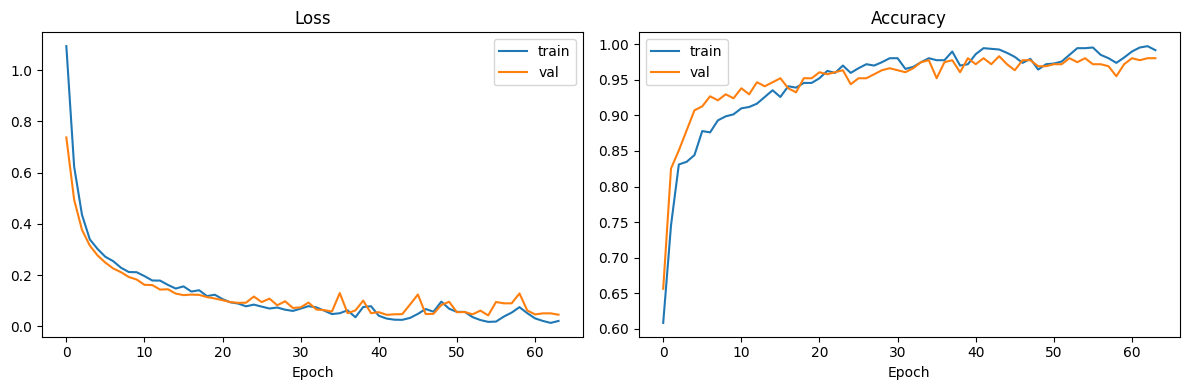

In [15]:
# --- Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

12/12 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

pointer_move       1.00      1.00      1.00       204
  left_click       0.96      0.99      0.97        93
   drag_hold       0.98      0.91      0.95        58

    accuracy                           0.98       355
   macro avg       0.98      0.97      0.97       355
weighted avg       0.98      0.98      0.98       355



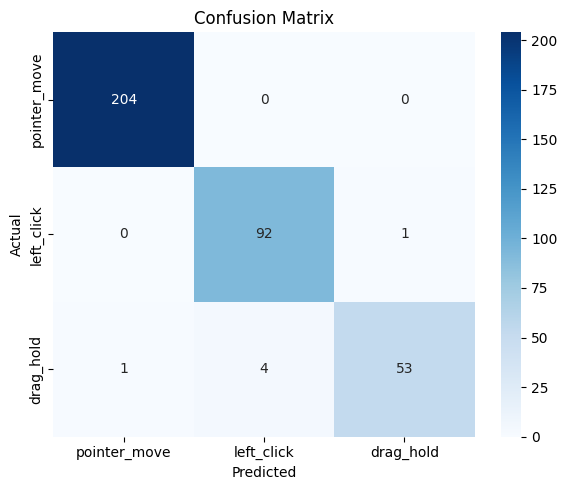

In [17]:
# --- Classification report + Confusion matrix ---
y_pred = np.argmax(model.predict(X_val), axis=1)

# Only use classes present in the data
present_labels = sorted(set(y_val) | set(y_pred))
present_names = [CLASS_NAMES[i] for i in present_labels]

print(classification_report(y_val, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_val, y_pred, labels=present_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=present_names, yticklabels=present_names, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Export to TFLite

In [18]:
# --- Convert to TFLite (dynamic quantization) ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_SAVE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_SAVE_PATH) / 1024
print(f"TFLite model saved: {TFLITE_SAVE_PATH} ({size_kb:.1f} KB)")

INFO:tensorflow:Assets written to: /tmp/tmpd0r1wp9_/assets


INFO:tensorflow:Assets written to: /tmp/tmpd0r1wp9_/assets


TFLite model saved: model/temporal_classifier/temporal_classifier.tflite (95.3 KB)


2026-04-16 23:09:23.453146: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 23:09:23.453165: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 23:09:23.453418: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd0r1wp9_
2026-04-16 23:09:23.455017: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 23:09:23.455025: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpd0r1wp9_
2026-04-16 23:09:23.458506: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-16 23:09:23.459661: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 23:09:23.488018: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpd0r1wp9_
2026-04

In [19]:
# --- Verify TFLite inference ---
interpreter = tf.lite.Interpreter(model_path=TFLITE_SAVE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input:  {input_details[0]['shape']}")
print(f"Output: {output_details[0]['shape']}")

# Compare Keras vs TFLite on a few samples
n_check = min(10, len(X_val))
keras_preds = np.argmax(model.predict(X_val[:n_check]), axis=1)
tflite_preds = []
for i in range(n_check):
    interpreter.set_tensor(
        input_details[0]["index"], X_val[i : i + 1].astype(np.float32)
    )
    interpreter.invoke()
    scores = interpreter.get_tensor(output_details[0]["index"])
    tflite_preds.append(int(np.argmax(scores)))

print(f"\nKeras  preds: {list(keras_preds)}")
print(f"TFLite preds: {tflite_preds}")
print(f"Match: {np.array_equal(keras_preds, tflite_preds)}")

Input:  [ 1 20 93]
Output: [1 5]
1/1 [==============================] - 0s 9ms/step

Keras  preds: [1, 1, 1, 3, 1, 2, 1, 3, 3, 1]
TFLite preds: [1, 1, 1, 3, 1, 2, 1, 3, 3, 1]
Match: True


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


**Done!** The trained TFLite model is at `model/temporal_classifier/temporal_classifier.tflite`.

Use `TemporalClassifier` wrapper to load it for inference:
```python
from model.temporal_classifier import TemporalClassifier
tc = TemporalClassifier()
class_id, scores = tc(window)  # window: (20, 93) ndarray
```